---
title: "Iris"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Iris Flowers
- **description:** Four petal and sepal measurements for 150 iris flowers, evenly split across three species (50 each) — the canonical classification dataset.
- **provenance:** Fisher, R. A. (1936), "The use of multiple measurements in taxonomic problems," *Annals of Eugenics* 7; specimens collected by botanist Edgar Anderson.
- **format:** long / tidy — 150 rows x 5 columns.

**Data dictionary**

- `sepal_length` — *(measurement)* sepal length in centimetres.
- `sepal_width` — *(measurement)* sepal width in centimetres.
- `petal_length` — *(measurement)* petal length in centimetres.
- `petal_width` — *(measurement)* petal width in centimetres.
- `species` — *(identifier)* `setosa`, `versicolor`, or `virginica`.

**Structure**

- **Rows:** 150 — one row per flower.
- **Columns:** 5.
- **Identifiers:** `species`.
- **Measurements:** the four centimetre dimensions.

**Use cases**

- classification and clustering demonstrations
- pairwise scatter matrices
- per-species aggregation of measurements


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

Every row is an actual observation, i.e. it represents a unique plant.

In [2]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


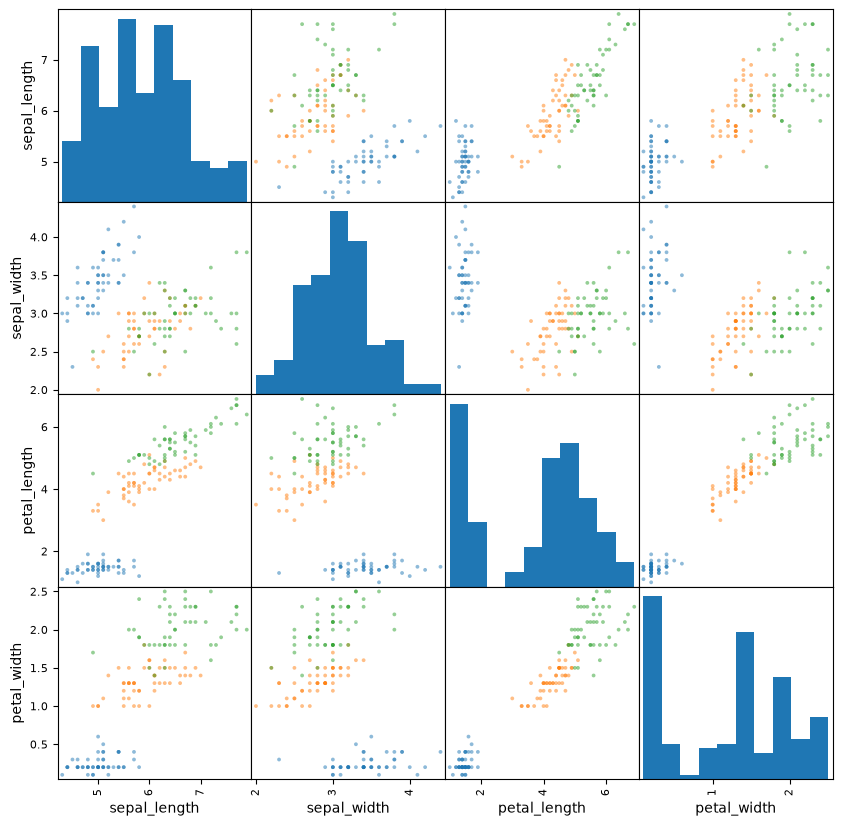

In [66]:
cmap = plt.get_cmap('tab10')
color_map = {species:cmap(i) for i, species in enumerate(iris['species'].unique())}
pd.plotting.scatter_matrix(iris, c=iris.species.map(color_map), figsize=(10,10), s=30, alpha=.5)
plt.show()

### Long form, aggregated

In [17]:
iris1 = iris.groupby('species').agg(['mean','min','max'])
iris1

sepal_length           sepal_width           petal_length       \
                   mean  min  max        mean  min  max         mean  min   
species                                                                     
setosa            5.006  4.3  5.8       3.428  2.3  4.4        1.462  1.0   
versicolor        5.936  4.9  7.0       2.770  2.0  3.4        4.260  3.0   
virginica         6.588  4.9  7.9       2.974  2.2  3.8        5.552  4.5   

                petal_width            
            max        mean  min  max  
species                                
setosa      1.9       0.246  0.1  0.6  
versicolor  5.1       1.326  1.0  1.8  
virginica   6.9       2.026  1.4  2.5

In [5]:
iris2 = iris1.swaplevel(axis=1)['mean']
iris2

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


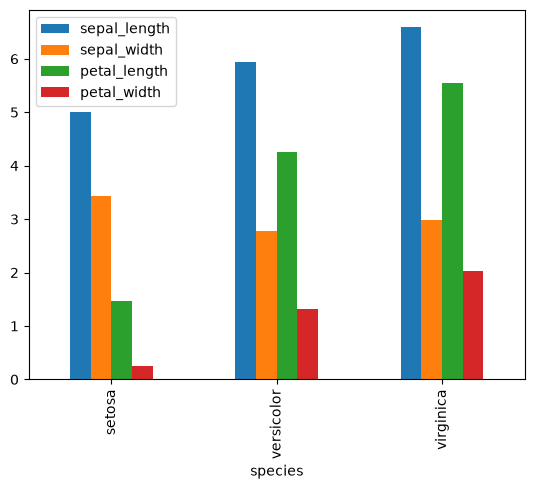

In [68]:
iris2.plot.bar()
plt.show()

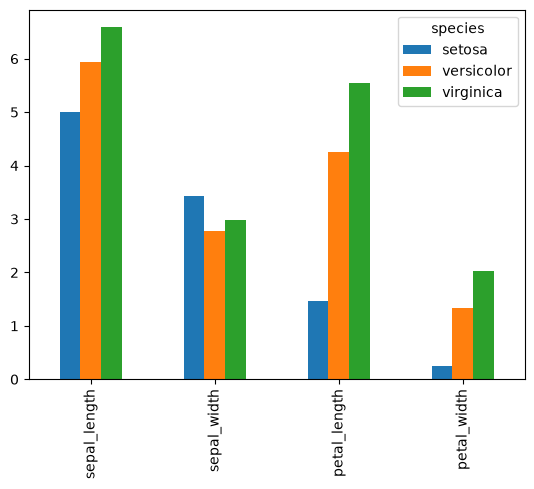

In [69]:
iris2.T.plot.bar()
plt.show()